# Proyecto 4

In [1]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split,GridSearchCV,learning_curve,ShuffleSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score, log_loss
import pandas as pd
import numpy as np
from sklearn import preprocessing as ps
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from scipy.optimize import minimize
from sklearn.cluster import KMeans
from sklearn import svm
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
delta=pd.read_csv("Delta.csv")
beta=pd.read_csv("Beta.csv")
alpha=pd.read_csv("Alpha.csv")
theta=pd.read_csv("Theta.csv")
gamma=pd.read_csv("Gamma.csv")

In [3]:
a=[delta,beta,alpha,theta,gamma]
nombres_canales = ["Estado","prom_delta","prom_beta","prom_alpha","prom_theta","prom_gamma","var_delta","var_beta","var_alpha","var_theta","var_gamma","sum_delta","sum_beta","sum_alpha","sum_theta","sum_gamma"]
nom=["delta","beta","alpha","theta","gamma"]
d2=pd.DataFrame(columns=nombres_canales)
d2["Estado"]=delta[delta.columns[0]]
con=0
for i in a:
    names=i.columns[1:]
    b=np.mean(i[names],axis=1)
    b=b-np.mean(b)
    d2["prom_"+nom[con]]=b
    var=i[names].var(axis=1)
    d2["var_"+nom[con]]=var
    s=np.sum(i[names],axis=1)
    d2["sum_"+nom[con]]=s
    con+=1
d2.head()

,Estado,prom_delta,prom_beta,prom_alpha,prom_theta,prom_gamma,var_delta,var_beta,var_alpha,var_theta,var_gamma,sum_delta,sum_beta,sum_alpha,sum_theta,sum_gamma
0,Alzheimer,-0.031545,0.135028,-0.066758,-0.053596,0.017056,0.002039,0.001893,0.005309,0.000037,0.000711,0.896216,3.333156,2.147644,1.036069,0.584994
1,Alzheimer,-0.022419,-0.005110,0.115196,-0.099633,0.011873,0.001262,0.001864,0.002097,0.000542,0.001104,0.969218,2.212052,3.603279,0.667767,0.543533
2,Alzheimer,-0.049023,0.271522,-0.148311,-0.068793,-0.005188,0.002563,0.003807,0.000287,0.000501,0.000299,0.756391,4.425115,1.495221,0.914491,0.407045
3,Alzheimer,0.107240,0.023758,-0.212440,0.041775,0.039497,0.003392,0.001504,0.000400,0.001214,0.006020,2.006492,2.443002,0.982192,1.799037,0.764519
4,Alzheimer,-0.076425,-0.088306,0.286702,-0.086350,-0.035380,0.002837,0.003699,0.013839,0.000686,0.000186,0.537170,1.546484,4.975322,0.774034,0.165508


In [4]:
d3=pd.read_csv("promedios.csv")
d3

,Estado,FP1,FP2,C3,C4,P7,P8,O1,O2
0,Alzheimer,0.199964,0.199957,0.199959,0.199943,0.199970,0.199931,0.199932,0.199960
1,Alzheimer,0.199928,0.199919,0.199974,0.199962,0.199916,0.199937,0.199788,0.199748
2,Alzheimer,0.199972,0.199951,0.199967,0.199908,0.199929,0.199972,0.199977,0.199978
3,Alzheimer,0.199932,0.199932,0.199964,0.199966,0.199962,0.199934,0.199847,0.199513
4,Alzheimer,0.199890,0.199929,0.199984,0.199983,0.199976,0.199960,0.199991,0.199991
5,Alzheimer,0.199943,0.199959,0.199963,0.199967,0.199969,0.199982,0.199973,0.199977
6,Alzheimer,0.199973,0.199975,0.199968,0.199969,0.199973,0.199950,0.199979,0.199975
7,Alzheimer,0.199906,0.199916,0.199963,0.199948,0.199936,0.199951,0.199581,0.199623
8,Alzheimer,0.199971,0.199973,0.199862,0.199792,0.199969,0.199969,0.199956,0.199922
9,Alzheimer,0.199907,0.199877,0.199371,0.199898,0.199816,0.199910,0.199962,0.199969


In [5]:
# a=[delta,beta,alpha,theta]
# nombres_canales = ["Estado","prom_delta","prom_beta","prom_alpha","prom_theta","var_delta","var_beta","var_alpha","var_theta","sum_delta","sum_beta","sum_alpha","sum_theta"]
# nom=["delta","beta","alpha","theta"]
# d2=pd.DataFrame(columns=nombres_canales)
# d2["Estado"]=delta[delta.columns[0]]
# con=0
# for i in a:
#     names=i.columns[1:]
#     b=np.mean(i[names],axis=1)
#     b=b-np.mean(b)
#     d2["prom_"+nom[con]]=b
#     var=i[names].var(axis=1)
#     d2["var_"+nom[con]]=var
#     s=np.sum(i[names],axis=1)
#     d2["sum_"+nom[con]]=s
#     con+=1
# d2.head()

Inicialmente se hace un encoder para convertir las variables cualitativas en cuantitativas en este caso solo afectando la columna de estados

In [6]:
encoder = ps.LabelEncoder()
d2["Estado"]=encoder.fit_transform(d2["Estado"])
print(d2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Estado      45 non-null     int32  
 1   prom_delta  45 non-null     float64
 2   prom_beta   45 non-null     float64
 3   prom_alpha  45 non-null     float64
 4   prom_theta  45 non-null     float64
 5   prom_gamma  45 non-null     float64
 6   var_delta   45 non-null     float64
 7   var_beta    45 non-null     float64
 8   var_alpha   45 non-null     float64
 9   var_theta   45 non-null     float64
 10  var_gamma   45 non-null     float64
 11  sum_delta   45 non-null     float64
 12  sum_beta    45 non-null     float64
 13  sum_alpha   45 non-null     float64
 14  sum_theta   45 non-null     float64
 15  sum_gamma   45 non-null     float64
dtypes: float64(15), int32(1)
memory usage: 5.6 KB
None


In [7]:
encoder = ps.LabelEncoder()
d3["Estado"]=encoder.fit_transform(d3["Estado"])
print(d2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Estado      45 non-null     int32  
 1   prom_delta  45 non-null     float64
 2   prom_beta   45 non-null     float64
 3   prom_alpha  45 non-null     float64
 4   prom_theta  45 non-null     float64
 5   prom_gamma  45 non-null     float64
 6   var_delta   45 non-null     float64
 7   var_beta    45 non-null     float64
 8   var_alpha   45 non-null     float64
 9   var_theta   45 non-null     float64
 10  var_gamma   45 non-null     float64
 11  sum_delta   45 non-null     float64
 12  sum_beta    45 non-null     float64
 13  sum_alpha   45 non-null     float64
 14  sum_theta   45 non-null     float64
 15  sum_gamma   45 non-null     float64
dtypes: float64(15), int32(1)
memory usage: 5.6 KB
None


En este caso 0:alz 1:control

## Normalización

Normalizaremos los valores de cada columna dividiéndolos por el valor máximo para tener valores entre 0 y 1 en cada columna, para ello cada vez que tengamos un Xtv entrenaremos un modelo con estos datos y Xts,Xtv se transformaran bajo dicho modelo se normalizaran los datos usando la función StandardScaler

Ahora revisemos la correlación con nuestro target de predicción que seria el estado

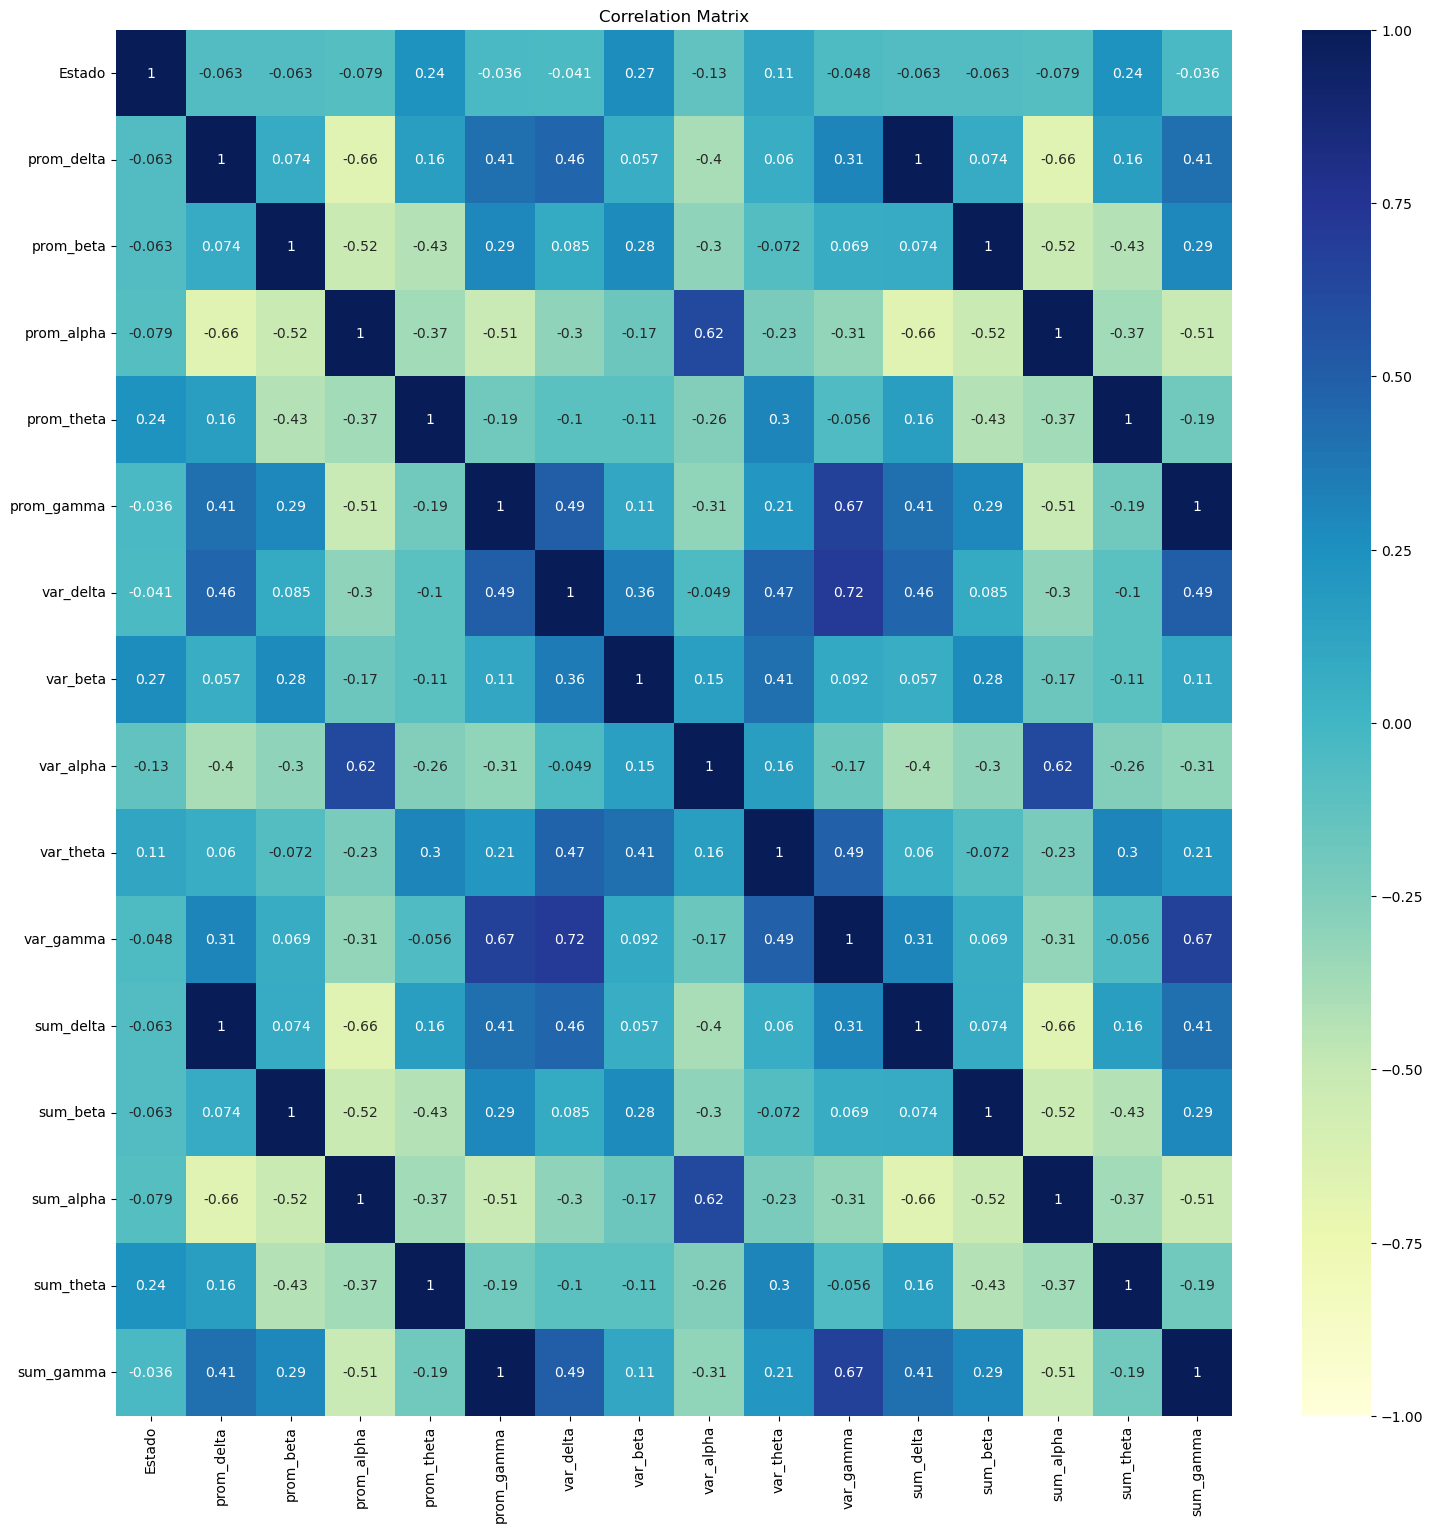

In [8]:
corr_matrix = d2.corr()
plt.figure(figsize=(18,18))
sns.heatmap(corr_matrix, annot = True, vmin = -1, vmax = 1, cmap = "YlGnBu").set_title('Correlation Matrix')
plt.show()

In [9]:
target_corr_df = pd.DataFrame(corr_matrix["Estado"].sort_values(ascending=False))
target_corr_df 

,Estado
Estado,1.000000
var_beta,0.266769
prom_theta,0.238015
sum_theta,0.238015
var_theta,0.113582
prom_gamma,-0.035799
sum_gamma,-0.035799
var_delta,-0.041289
var_gamma,-0.047635
sum_beta,-0.062527


In [10]:
d2=d2[target_corr_df.index[:5]]
d2.head()

,Estado,var_beta,prom_theta,sum_theta,var_theta
0,0,0.001893,-0.053596,1.036069,0.000037
1,0,0.001864,-0.099633,0.667767,0.000542
2,0,0.003807,-0.068793,0.914491,0.000501
3,0,0.001504,0.041775,1.799037,0.001214
4,0,0.003699,-0.086350,0.774034,0.000686


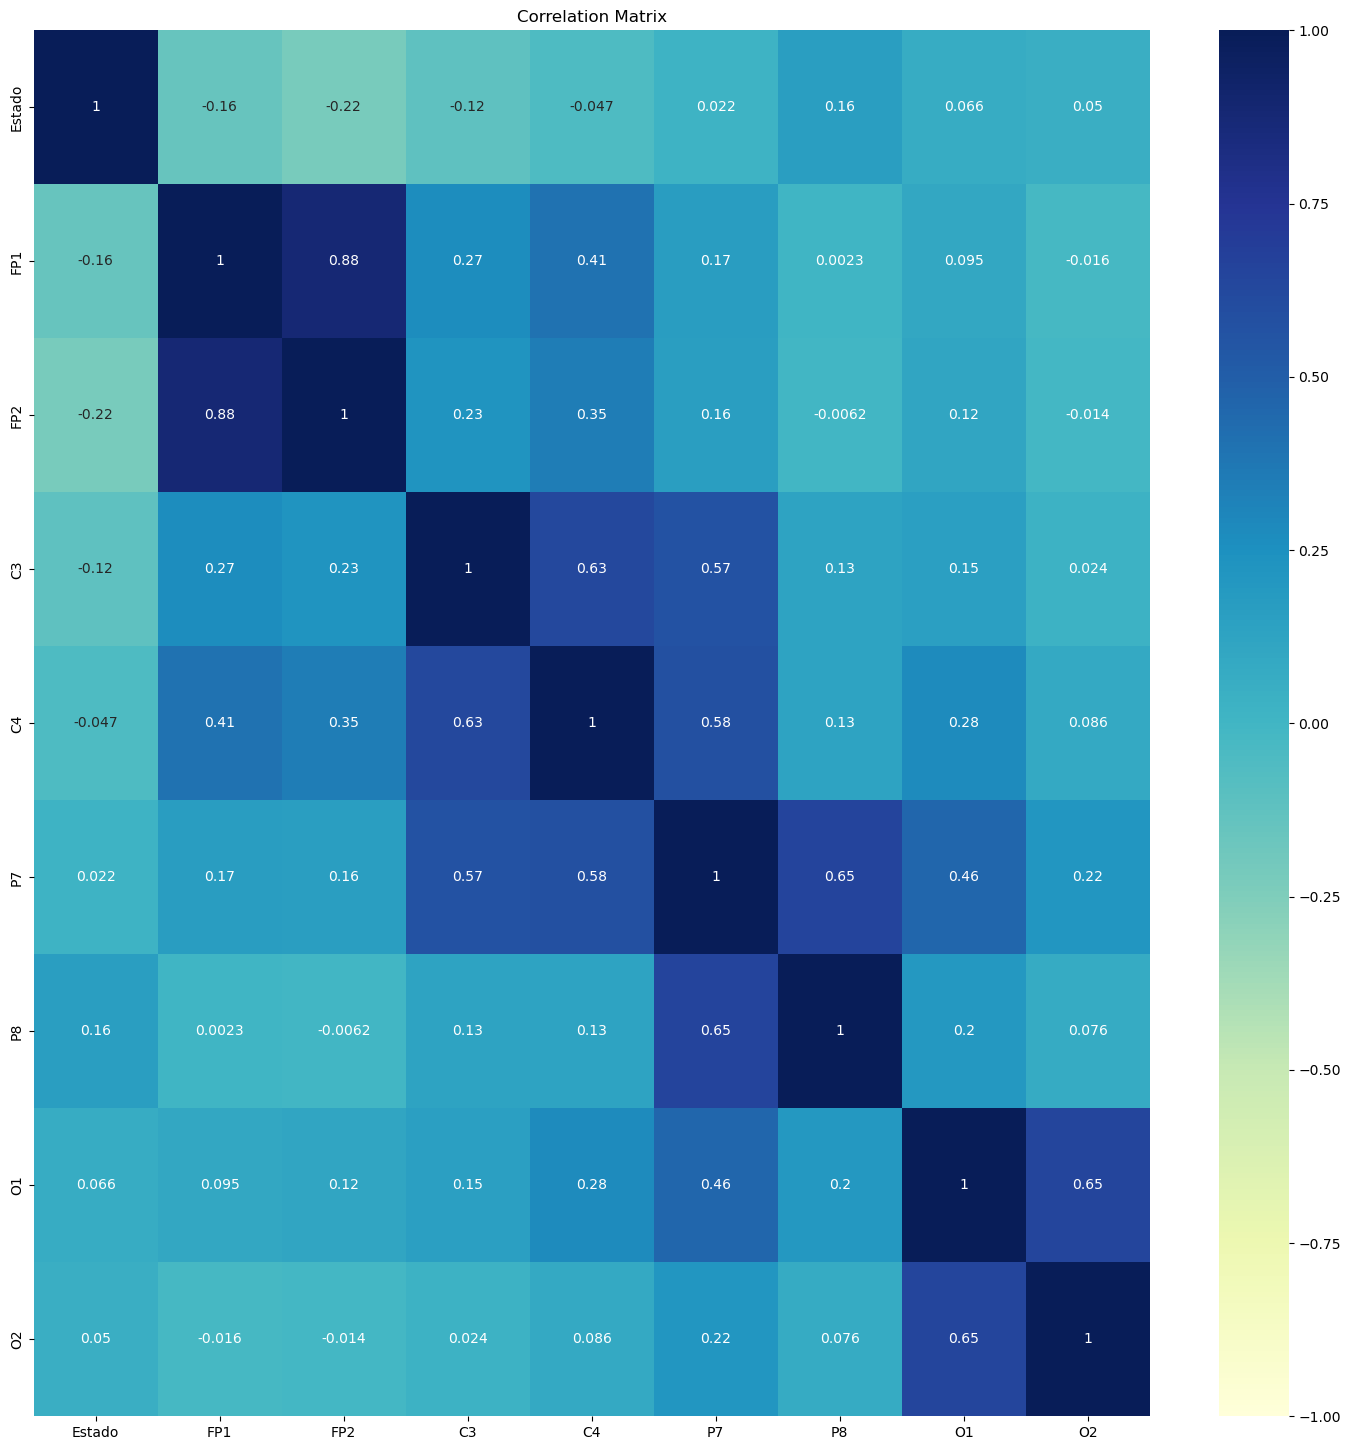

In [11]:
corr_matrix = d3.corr()
plt.figure(figsize=(18,18))
sns.heatmap(corr_matrix, annot = True, vmin = -1, vmax = 1, cmap = "YlGnBu").set_title('Correlation Matrix')
plt.show()

In [12]:
target_corr_df = pd.DataFrame(corr_matrix["Estado"].sort_values(ascending=False))
target_corr_df

,Estado
Estado,1.000000
P8,0.160519
O1,0.065574
O2,0.049597
P7,0.022318
C4,-0.047437
C3,-0.122198
FP1,-0.155294
FP2,-0.218978


En este caso podemos observar que el estado va relacionado mayormente con la mediana que en el caso de la varianza o la suma, con esto en mente priorizaremos este parámetro para la generación de las redes neuronales

In [13]:
def lc_plot(estimator,X,y):
    train_sizes, train_scores, valid_scores = learning_curve(estimator, X, y,train_sizes= [0.3, 0.5,0.7,0.9],
                 scoring ='f1_macro', cv = ShuffleSplit(n_splits=10, test_size=val_size))
    
    train_scores = np.abs(train_scores)
    valid_scores = np.abs(valid_scores)

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)

    valid_mean = np.mean(valid_scores, axis=1)
    valid_std = np.std(valid_scores, axis=1)

    plt.subplots(1, figsize=(5,5))
    plt.plot(train_sizes, train_mean, '--', color="r",  label="Training score")
    plt.plot(train_sizes, valid_mean, color="g", label="Cross-validation score")



    plt.grid()
    plt.title("Learning Curve")
    plt.xlabel("Training Set Size"), plt.ylabel("F1_macro"), plt.legend(loc="best")
    plt.tight_layout()
    plt.show()
    return plt

## Funciones de perdida para optimización

- En este caso usamos F1 , debido a que es mejor métrica para los sistemas binarios como son el caso de los primeros ejemplos.

Adicionalmente vamos a ver las curvas de aprendizaje para evitar el sobreentrenamiento con los datos dados

## 1.1 Funciones

In [14]:
from itertools import product
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Reds):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    fig=plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [29]:
def metrics(a,Xtv,ytv,Xts,yts,target_names):
    def class_plot(report,class_labels):
        class_labels.remove('accuracy')
        metrics = np.zeros((len(class_labels), 3))
        for idx, label in enumerate(class_labels):
            metrics[idx, 0] = report[label]['precision']
            metrics[idx, 1] = report[label]['recall']
            metrics[idx, 2] = report[label]['f1-score']
        accuracy = report['accuracy']
        fig, ax = plt.subplots()
        heatmap = sns.heatmap(metrics, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
        ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'])
        ax.set_yticklabels(class_labels, rotation='horizontal')
        cbar = ax.collections[0].colorbar
        cbar.set_label('Metric Value')
        ax.set_title('Heat Map Classification Report')
        plt.figtext(0.45, 0.02, f"Accuracy: {accuracy:.5f}", ha="center", fontsize=12, bbox={"facecolor": "orange", "alpha": 0.5, "pad": 5})
        plt.show()
    a.fit(Xtv,ytv)
    predict_train = a.predict(Xtv)
    predict_test = a.predict(Xts)
    print("Train ",a.activation)
    print("------------")

    report = classification_report(ytv,predict_train, output_dict=True)
    class_labels = list(report.keys())
    class_plot(report,class_labels)

    mc_train = confusion_matrix(ytv,predict_train)
    plot_confusion_matrix(mc_train, classes=target_names,title='Confusion matrix train '+a.activation,normalize=True)
    print("Test ",a.activation)
    print("------------")
    report = classification_report(yts,predict_test, output_dict=True)
    class_labels = list(report.keys())
    class_plot(report,class_labels)

    mc_train = confusion_matrix(yts,predict_test)
    plot_confusion_matrix(mc_train, classes=target_names,title='Confusion matrix test '+a.activation,normalize=True)

In [16]:
def tuple_generator1(start, end):
        for i in range(start, end + 1):
            yield (i, i, i)

In [17]:
def tuple_generator(start, end):
    return list(itertools.product(range(start, end+ 1), repeat=3))

In [18]:
def aplicar_m(i,Xtv,ytv,Xts,yts,target_names):
    for a in i:
        metrics(a,Xtv,ytv,Xts,yts,target_names)

En este caso vamos a probar con varias redes neuronales, cambiaremos la activación para cambiar la arquitectura lo mismo que el solucionador de ser necesario, esto cambiara la forma del sigmoide, en el proceso se ira permutando los valores hasta encontrar un modelo más adecuado para la predicción 

##  Resultados

In [19]:
x=d2.drop(["Estado"],axis=1)
y=d2.Estado.values
test_size = 0.35
val_size  = test_size/(1-test_size) # Elementos de validación


print (x.shape, y.shape)
print ("test size %.2f"%test_size)
print ("val size is %.2f (relative to %.2f) "%(val_size, 1-test_size))

Xtv, Xts, ytv, yts = train_test_split(x, y, test_size=test_size,stratify=y,random_state=23)
scaler=StandardScaler()
scaler.fit(Xtv)
Xtv=scaler.transform(Xtv)
Xts=scaler.transform(Xts)
print (Xtv.shape, Xts.shape)

(45, 4) (45,)
test size 0.35
val size is 0.54 (relative to 0.65) 
(29, 4) (16, 4)


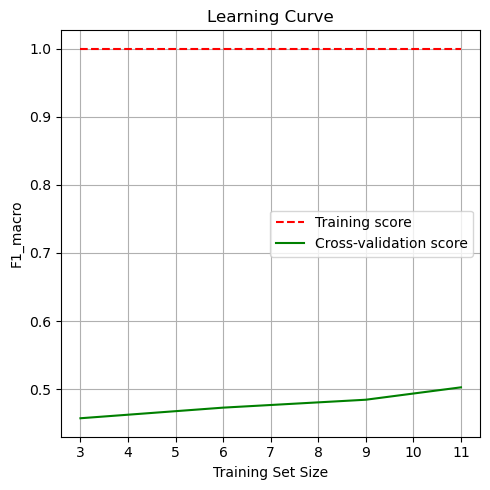

<module 'matplotlib.pyplot' from 'c:\\Users\\migue\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [24]:
mlp= MLPClassifier(hidden_layer_sizes=(20,20,20), activation='relu',solver='adam', max_iter=10000)

lc_plot(mlp,Xtv,ytv)

Train  relu
------------


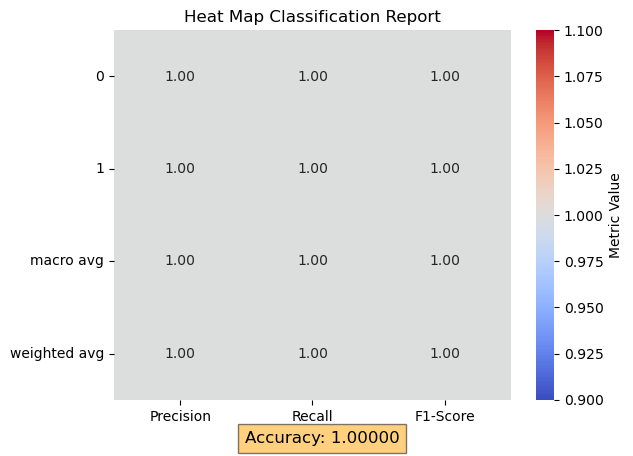

Normalized confusion matrix
Test  relu
------------


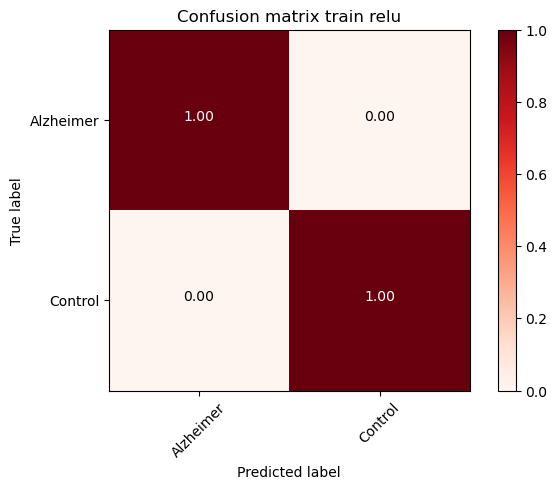

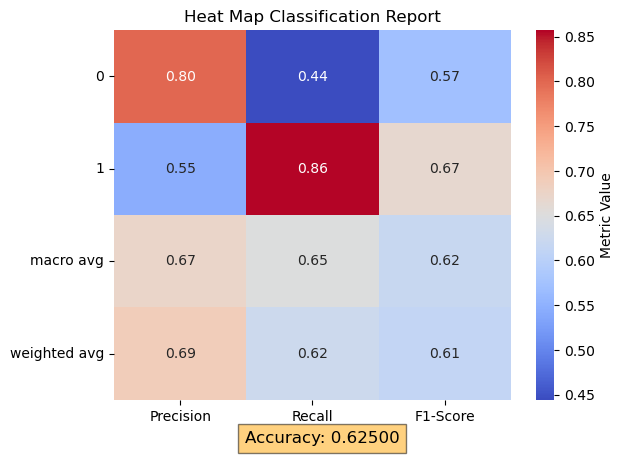

Normalized confusion matrix
Train  identity
------------


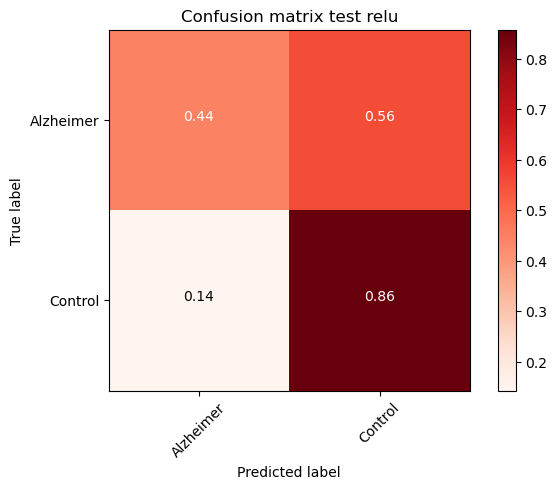

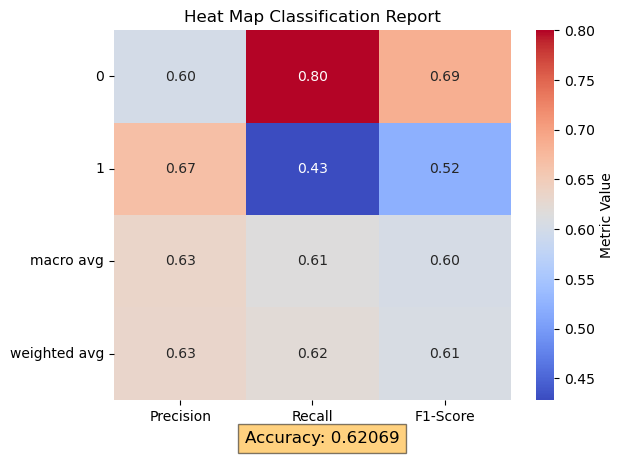

Normalized confusion matrix
Test  identity
------------


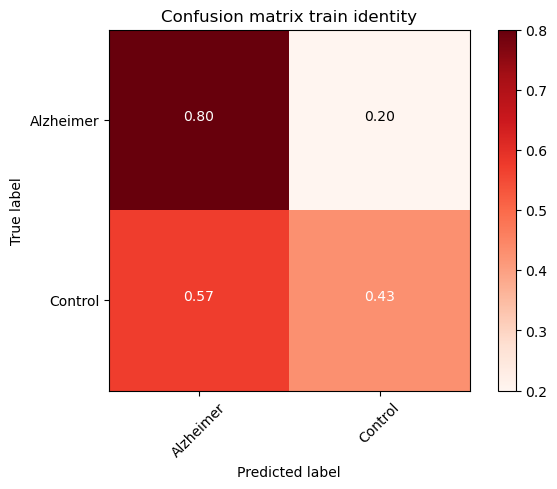

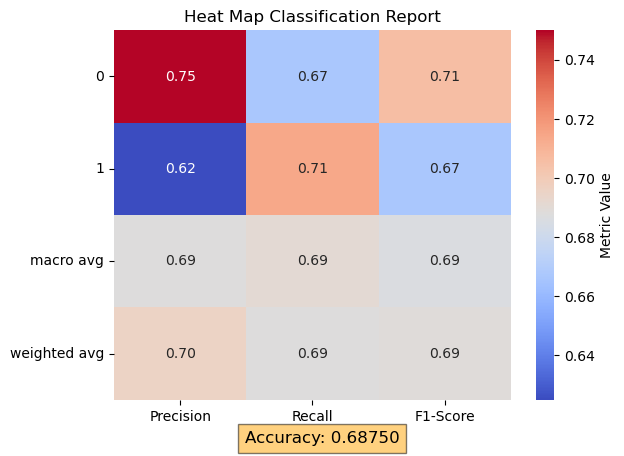

Normalized confusion matrix
Train  tanh
------------


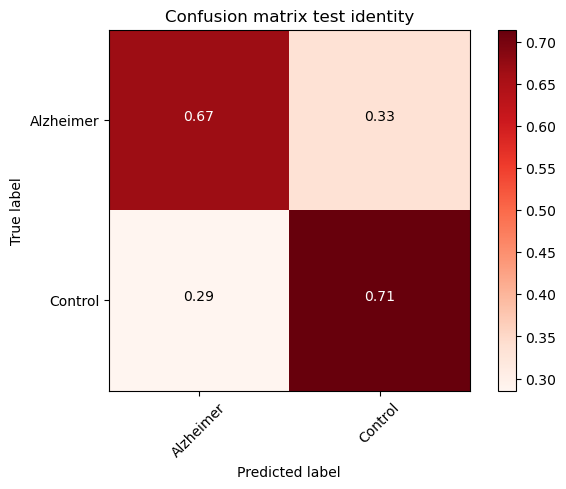

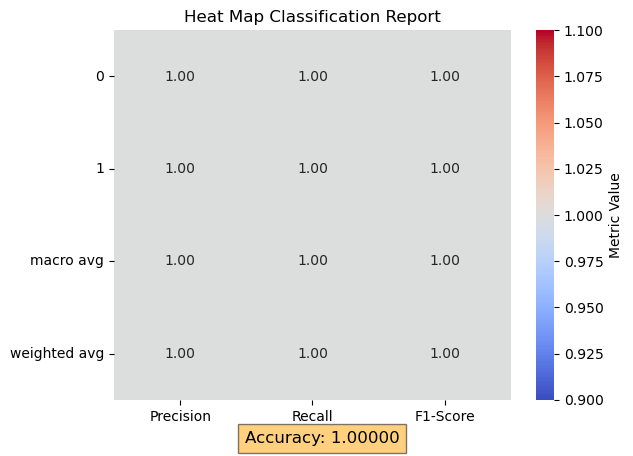

Normalized confusion matrix
Test  tanh
------------


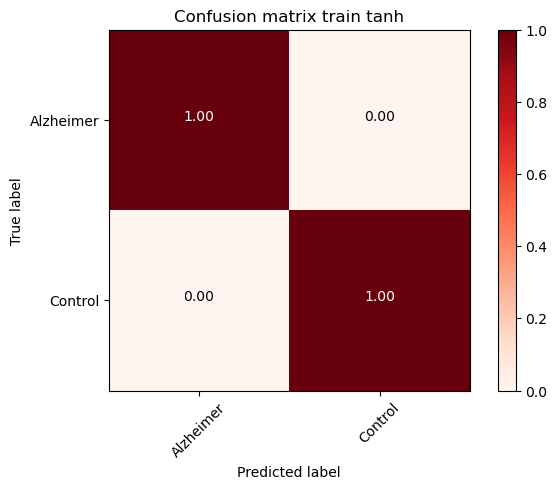

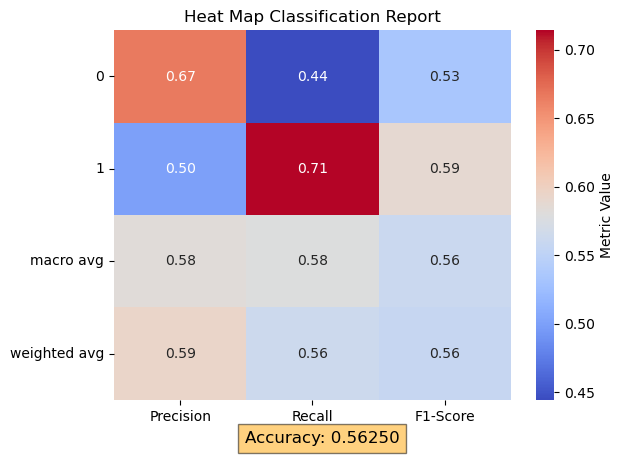

Normalized confusion matrix
Train  logistic
------------


c:\Users\migue\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\migue\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\migue\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


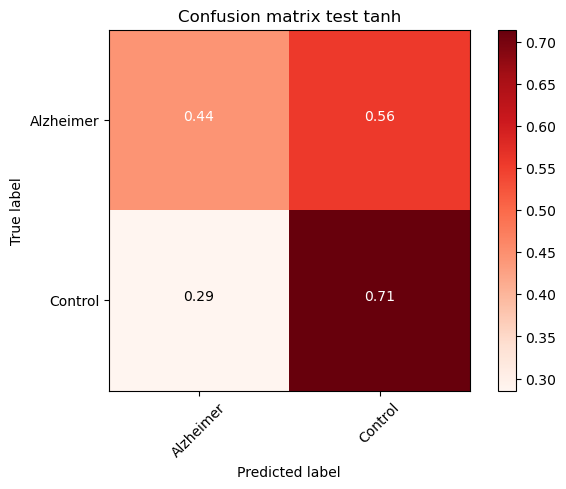

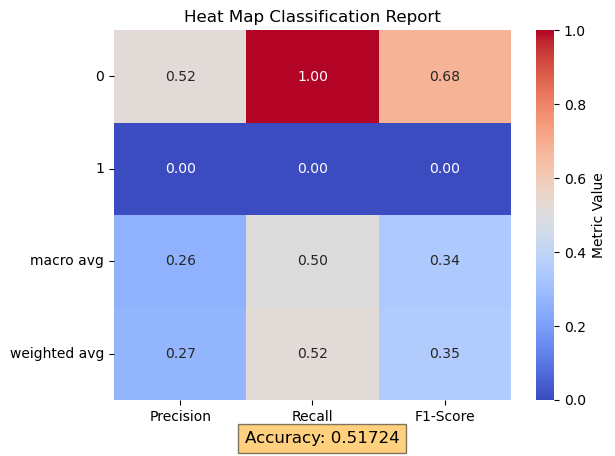

Normalized confusion matrix
Test  logistic
------------


c:\Users\migue\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\migue\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\migue\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


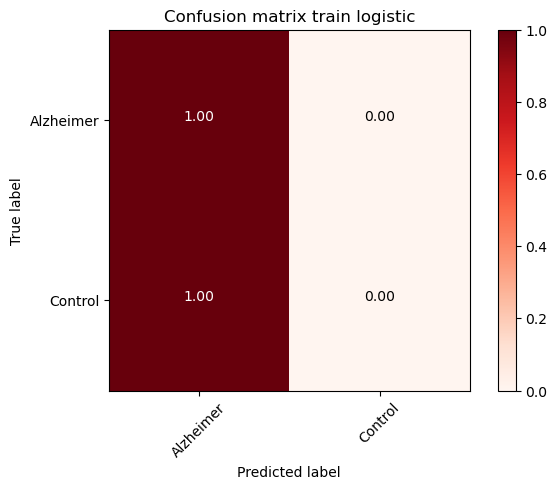

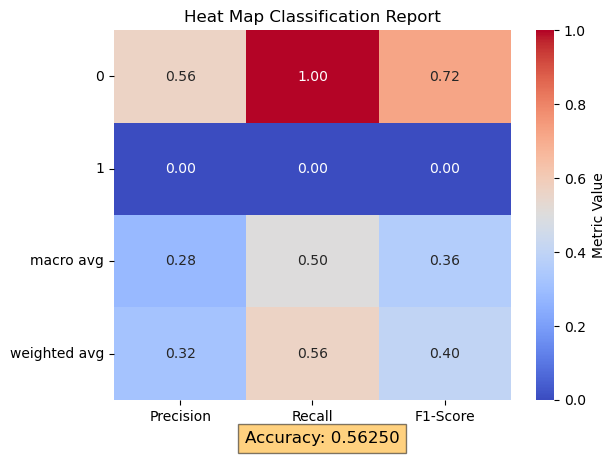

Normalized confusion matrix


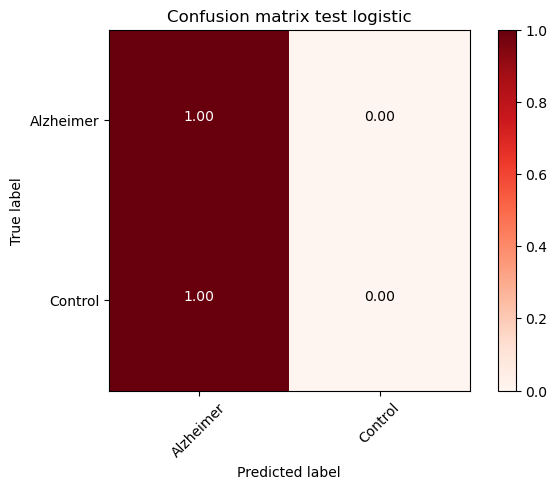

In [30]:
mlp_relu = MLPClassifier(hidden_layer_sizes=(20,20,20), activation='relu', solver='adam', max_iter=10000) 
mlp_identity = MLPClassifier(hidden_layer_sizes=(20,20,20), activation='identity', solver='adam', max_iter=10000) 
mlp_tanh = MLPClassifier(hidden_layer_sizes=(20,20,20), activation='tanh', solver='adam', max_iter=10000)
mlp_logic=MLPClassifier(hidden_layer_sizes=(20,20,20), activation='logistic', solver='adam', max_iter=10000)
a=[mlp_relu,mlp_identity,mlp_tanh,mlp_logic]
aplicar_m(a,Xtv,ytv,Xts,yts,['Alzheimer','Control'])

Generación de tuplas


In [31]:
max_iter=[10000]
it=list(tuple_generator1(1,45))
activation=['relu','identity','tanh','logistic']
param_grid = {'hidden_layer_sizes': it,"activation":activation,"max_iter":max_iter}
mlp= MLPClassifier(solver='adam')
grid_search = GridSearchCV(mlp, param_grid,
                           verbose=2,
                           scoring="f1_macro",
                           cv = ShuffleSplit(n_splits= 5, test_size=val_size),
                           n_jobs=-1)
grid_search.fit(Xtv, ytv)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
#Se crea la mejor red neuronal posible con los parametros anteriores
best=MLPClassifier(hidden_layer_sizes=best_params["hidden_layer_sizes"], 
                   activation=best_params["activation"], solver='adam', 
                   max_iter=best_params["max_iter"]) 
#Se busca una pequeña optimización con respecto a esos macroparametros, en este caso usando como puntuación la funcion f1

Fitting 5 folds for each of 180 candidates, totalling 900 fits


Best Parameters: {'activation': 'identity', 'hidden_layer_sizes': (35, 35, 35), 'max_iter': 10000}
Best Score: 0.607136204009269
Train  identity
------------


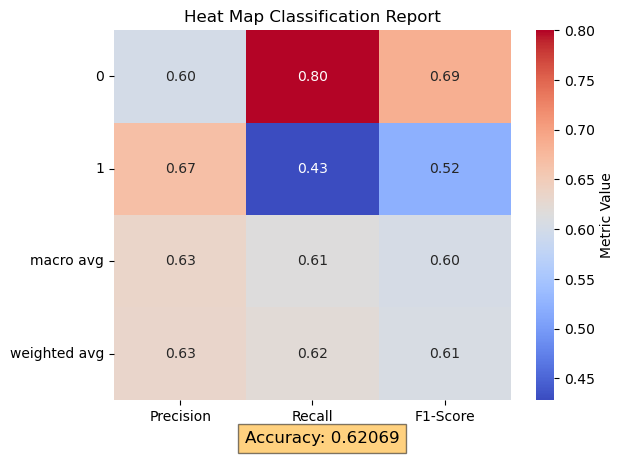

Normalized confusion matrix
Test  identity
------------


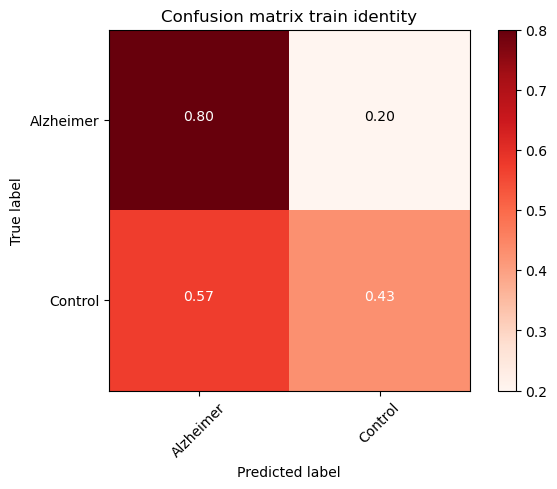

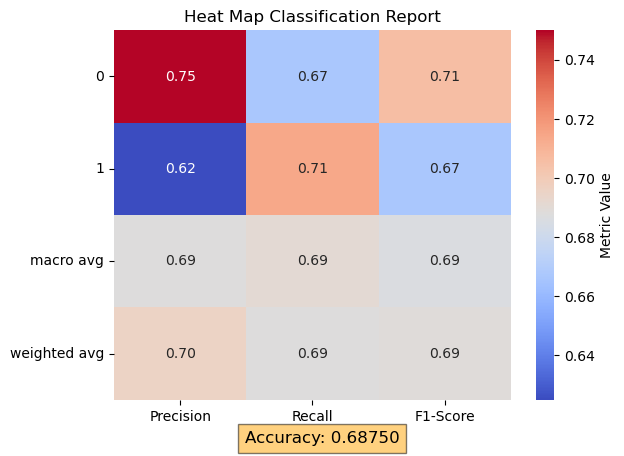

Normalized confusion matrix


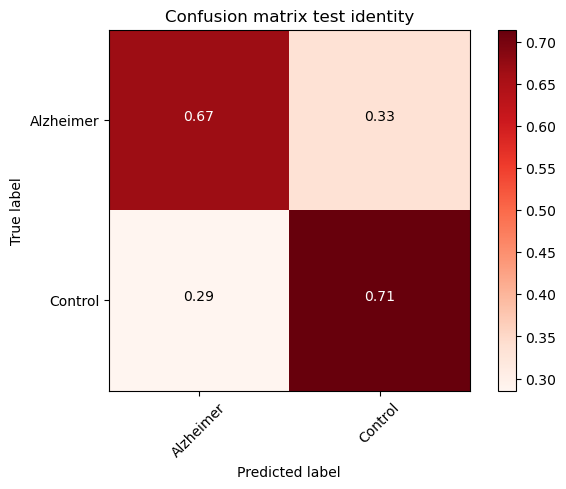

In [32]:
print("Best Parameters:", best_params)
print("Best Score:", best_score)
metrics(best,Xtv,ytv,Xts,yts,['Alzheimer','Control'])

In [33]:
sem,_,_=best.hidden_layer_sizes
if sem>5:
    start=sem-5
    end=sem+5
else:
    start=sem
    end=sem+5
it2=tuple_generator(start,end)
param_grid2 = {'hidden_layer_sizes': it2}
grid_search = GridSearchCV(best, param_grid2,
                           verbose=2,
                           scoring="f1_macro",
                           cv = ShuffleSplit(n_splits= 5, test_size=val_size),
                           n_jobs=-1)
grid_search.fit(Xtv, ytv)
best_params = grid_search.best_params_
best_score = grid_search.best_score_

#Se crea la mejor red neuronal posible con los parametros anteriores
the_bestest=MLPClassifier(hidden_layer_sizes=best_params["hidden_layer_sizes"],
                           activation=best.activation, 
                           solver='adam',
                             max_iter=best.max_iter) 

Fitting 5 folds for each of 1331 candidates, totalling 6655 fits


Best Parameters: {'hidden_layer_sizes': (33, 40, 33)}
Best Score: 0.5797570850202429
Train  identity
------------


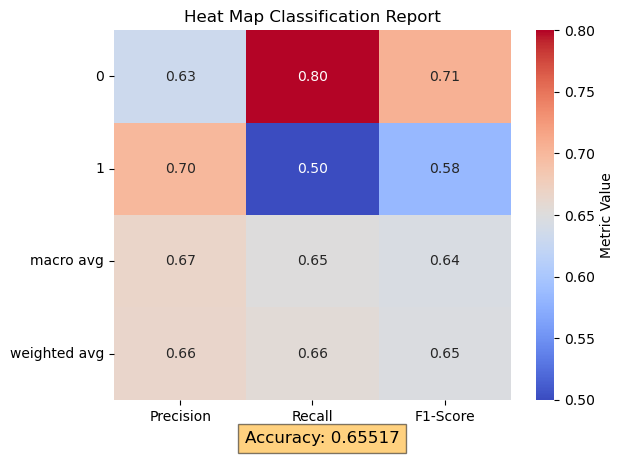

Normalized confusion matrix
Test  identity
------------


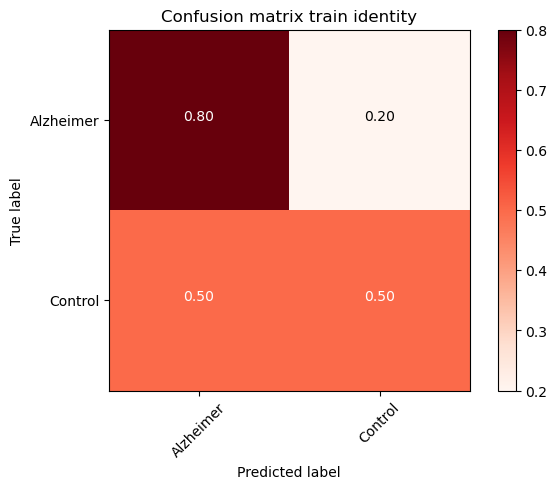

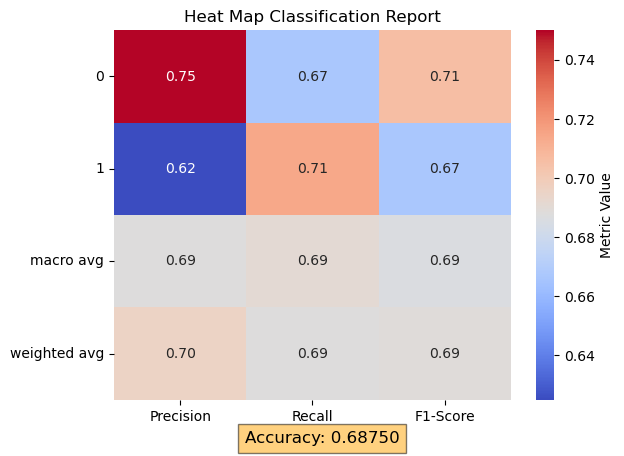

Normalized confusion matrix


MLPClassifier(activation='identity', hidden_layer_sizes=(33, 40, 33),
              max_iter=10000)

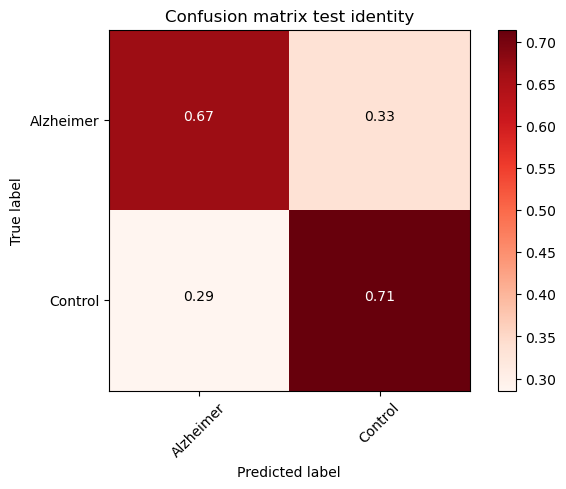

In [34]:
print("Best Parameters:", best_params)
print("Best Score:", best_score)
metrics(the_bestest,Xtv,ytv,Xts,yts,["Alzheimer","Control"])
the_bestest

 # Kmeans

In [12]:
from sklearn.metrics import silhouette_score, adjusted_rand_score
from mpl_toolkits.mplot3d import Axes3D

In [13]:
def plot_clusters(X,y):
    n_clusters = len(np.unique(y))
    cmap = plt.cm.bwr if n_clusters==2 else plt.cm.plasma
    cmap((y*255./(n_clusters-1)).astype(int))
    for i in np.unique(y):
        col = cmap((i*255./(n_clusters-1)).astype(int))
        Xr = X[y==i]
        plt.scatter(Xr[:,0], Xr[:,1], color=col, label="cluster %d"%i, alpha=.5)
    plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],marker="x", lw=5, s=200, color="black")
    plt.legend()    
    plt.xlabel("Varianza normalizada")
    plt.ylabel("Mediana normalizada")

In [21]:
def plot_clusters3D(X, y,plotcenter=False):

    name=["Alzheimer","Control"]
    n_clusters = len(np.unique(y))
    cmap = plt.cm.bwr if n_clusters == 2 else plt.cm.plasma
    cmap((y * 255. / (n_clusters - 1)).astype(int))
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    for i in np.unique(y):
        col = cmap((i * 255. / (n_clusters - 1)).astype(int))
        Xr = X[y == i]
        ax.scatter(Xr[:, 0], Xr[:, 1], Xr[:, 2], color=col, label=name[i], alpha=.5)
    if plotcenter:
        ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], km.cluster_centers_[:, 2],
                marker="x", lw=5, s=200, color="black")
    
    ax.legend(loc="best")
    ax.set_zlabel("var_beta")
    ax.set_ylabel("prom_theta")
    ax.set_xlabel("sum_theta")
   		 
    plt.show()

In [27]:
def plot_clusters_2d(X, y, centers,plotcenter=False):
    n_clusters = len(np.unique(y))
    cmap = plt.cm.bwr if n_clusters == 2 else plt.cm.plasma
    cmap((y * 255. / (n_clusters - 1)).astype(int))
    name=["Alzheimer","Control"]
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].set_xlabel("var_beta")
    axs[0].set_ylabel("prom_theta")
    axs[1].set_xlabel("var_beta")
    axs[1].set_ylabel("prom_theta")
    axs[2].set_xlabel("prom_theta")
    axs[2].set_ylabel("sum_theta")

    for i in np.unique(y):
        col = cmap((i * 255. / (n_clusters - 1)).astype(int))
        Xr = X[y == i]
        axs[0].scatter(Xr[:, 0], Xr[:, 1], color=col, label=name[i], alpha=.5)
        axs[1].scatter(Xr[:, 0], Xr[:, 2], color=col, label=name[i], alpha=.5)
        axs[2].scatter(Xr[:, 1], Xr[:, 2], color=col, label=name[i], alpha=.5)
    if plotcenter:
        axs[0].scatter(centers[:, 0], centers[:, 1], marker="x", color="black", label="Cluster Centers")
        axs[1].scatter(centers[:, 0], centers[:, 2], marker="x", color="black", label="Cluster Centers")
        axs[2].scatter(centers[:, 1], centers[:, 2], marker="x", color="black", label="Cluster Centers")

    axs[0].legend(loc="best")
    axs[1].legend(loc="best")
    axs[2].legend(loc="best")
    
    plt.tight_layout()
    plt.show()

###  Kmeans para los 2 tipos de pacientes 

In [16]:
x=d2.drop(["Estado"],axis=1)
y=d2.Estado.values
scaler=StandardScaler()
scaler.fit(x)
x_kms=scaler.transform(x)

In [17]:
km = KMeans(n_clusters=2, random_state=23, n_init="auto")
km.fit(x_kms)
y_kms=km.predict(x_kms)

c:\Users\migue\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


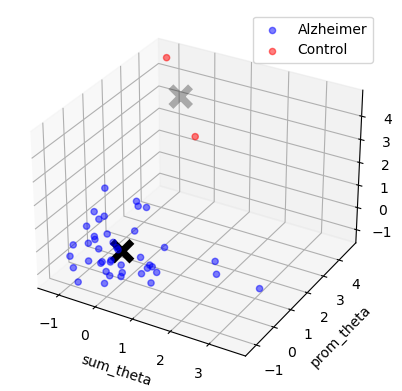

In [23]:
plot_clusters3D(x_kms,y_kms,plotcenter=True)

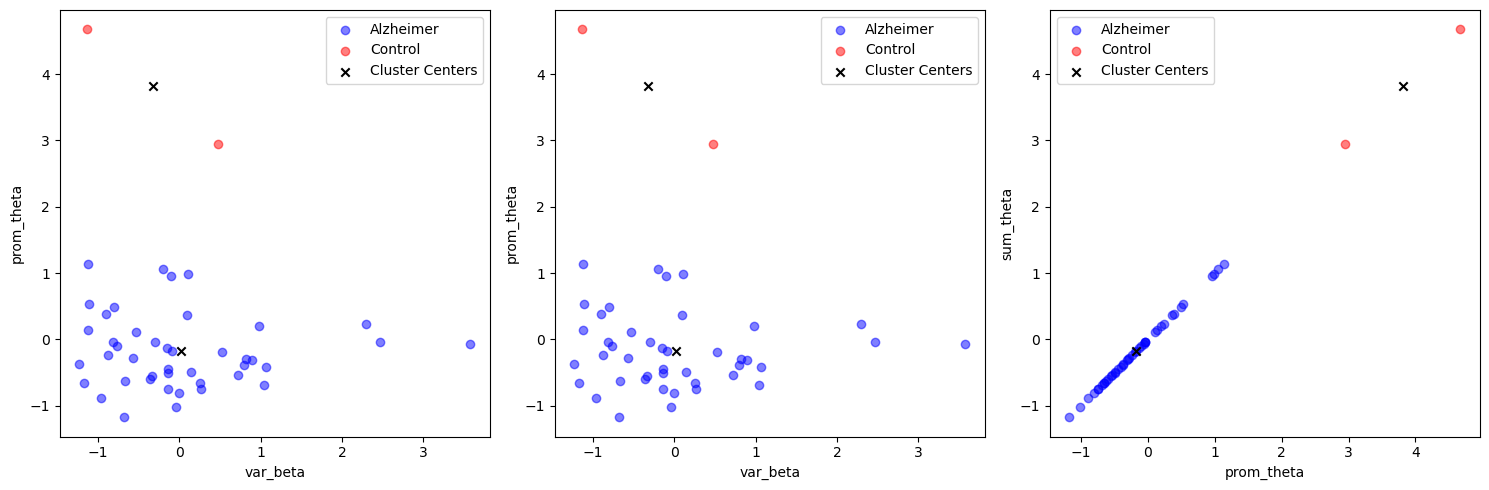

In [31]:
centers_kms = km.cluster_centers_
plot_clusters_2d(x_kms,y_kms,centers_kms,True)

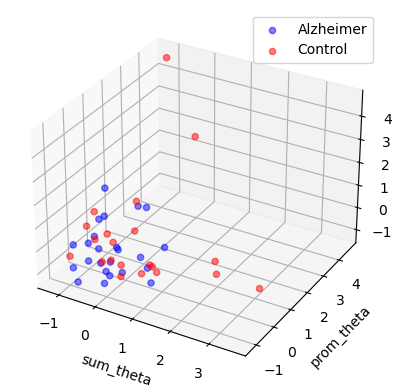

In [29]:
plot_clusters3D(x_kms,y)

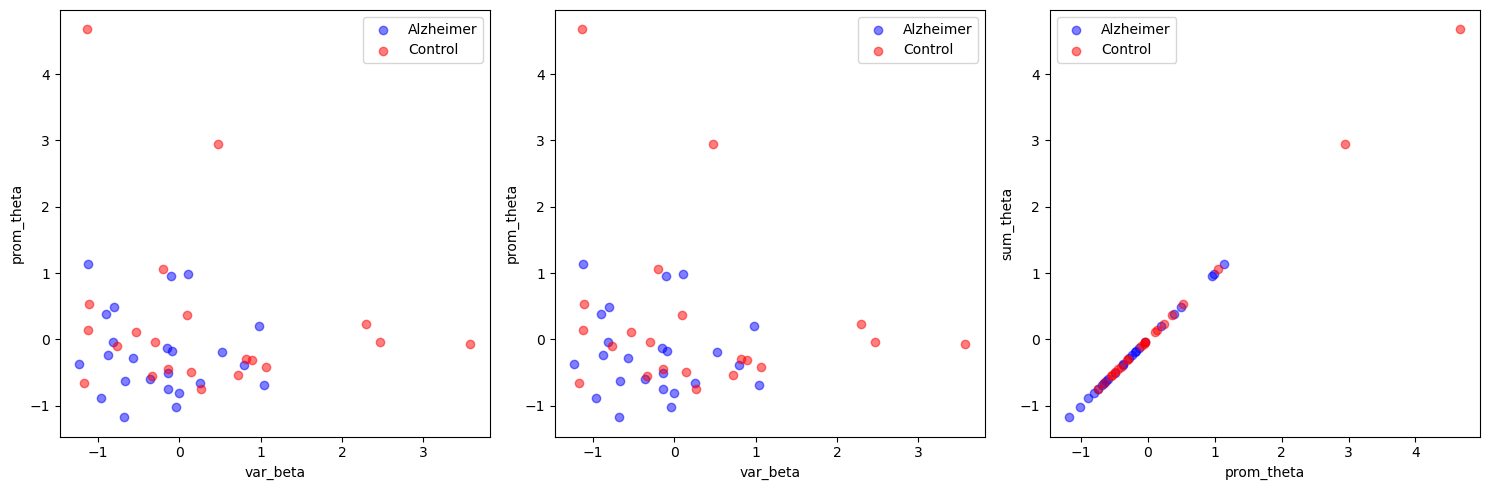

In [30]:
plot_clusters_2d(x_kms,y,centers_kms,False)

In [32]:
km.inertia_

115.25473451721055

In [33]:
silhouette_score(x_kms,km.labels_)

0.6470200337628058

In [34]:
adjusted_rand_score(y,km.labels_)

0.0167909097488601

##  SVC o matrices de soporte vectorial

In [58]:
#crackles y sano
x=d2.drop(["Estado"],axis=1)
y=d2.Estado.values
test_size = 0.3
val_size  = test_size/(1-test_size) # Elementos de validación


print (x.shape, y.shape)
print ("test size %.2f"%test_size)
print ("val size is %.2f (relative to %.2f) "%(val_size, 1-test_size))

Xtv, Xts, ytv, yts = train_test_split(x, y, test_size=test_size,stratify=y,random_state=23)
scaler=StandardScaler()
scaler.fit(Xtv)
Xtv=scaler.transform(Xtv)
Xts=scaler.transform(Xts)
print (Xtv.shape, Xts.shape)

(45, 4) (45,)
test size 0.30
val size is 0.43 (relative to 0.70) 
(31, 4) (14, 4)


In [60]:
clf = svm.SVC()
kernel=["linear","poly","rbf","sigmoid"]
c=[0.1,0.2,1,2]
param_grid3={"kernel":kernel,"C":c}
grid_search = GridSearchCV(clf, 
                           param_grid3,
                           verbose=2,
                           scoring="f1_macro",
                           cv = ShuffleSplit(n_splits= 5, test_size=val_size),
                           n_jobs=-1)
grid_search.fit(Xtv, ytv)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best=svm.SVC(kernel=best_params["kernel"],C=best_params["C"])
best

Fitting 5 folds for each of 16 candidates, totalling 80 fits


SVC(C=2, kernel='sigmoid')

In [61]:
def metrics2(a,name,target_names):
    def class_plot(report,class_labels):
            class_labels.remove('accuracy')
            metrics = np.zeros((len(class_labels), 3))
            for idx, label in enumerate(class_labels):
                metrics[idx, 0] = report[label]['precision']
                metrics[idx, 1] = report[label]['recall']
                metrics[idx, 2] = report[label]['f1-score']
            accuracy = report['accuracy']
            fig, ax = plt.subplots()
            heatmap = sns.heatmap(metrics, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
            ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'])
            ax.set_yticklabels(class_labels, rotation='horizontal')
            cbar = ax.collections[0].colorbar
            cbar.set_label('Metric Value')
            ax.set_title('Heat Map Classification Report')
            plt.figtext(0.45, 0.02, f"Accuracy: {accuracy:.5f}", ha="center", fontsize=12, bbox={"facecolor": "orange", "alpha": 0.5, "pad": 5})
            plt.show()
    a.fit(Xtv,ytv)
    predict_train = a.predict(Xtv)
    predict_test = a.predict(Xts)
    print("Train "+name)
    print("------------")

    report = classification_report(ytv,predict_train, output_dict=True)
    class_labels = list(report.keys())
    class_plot(report,class_labels)

    mc_train = confusion_matrix(ytv,predict_train)
    plot_confusion_matrix(mc_train, classes=target_names,title='Confusion matrix train SVC',normalize=True)
    print("------------")
    print("Test "+name)
    report = classification_report(yts,predict_test, output_dict=True)
    class_labels = list(report.keys())
    class_plot(report,class_labels)

    mc_train = confusion_matrix(yts,predict_test)
    plot_confusion_matrix(mc_train, classes=target_names,title='Confusion matrix test SVC',normalize=True)

Train SVC
------------


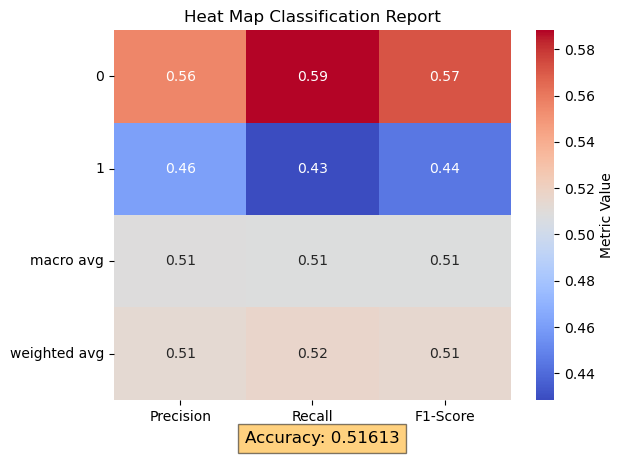

Normalized confusion matrix
------------
Test SVC


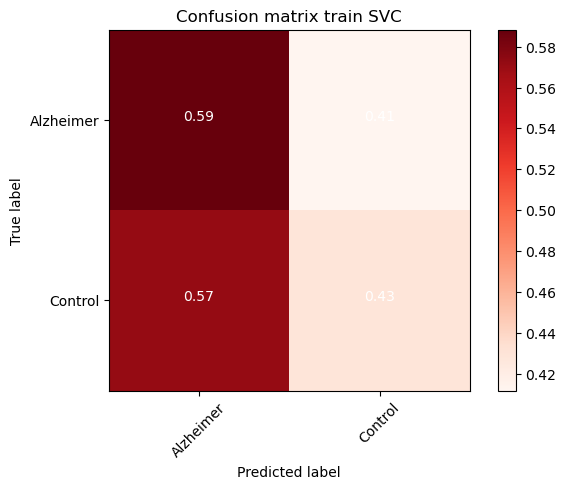

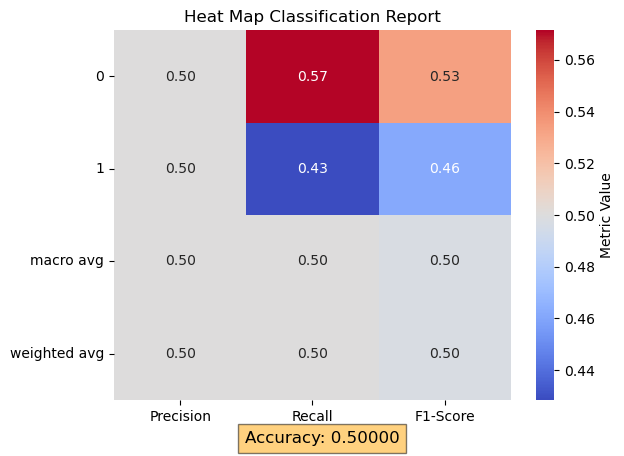

Normalized confusion matrix


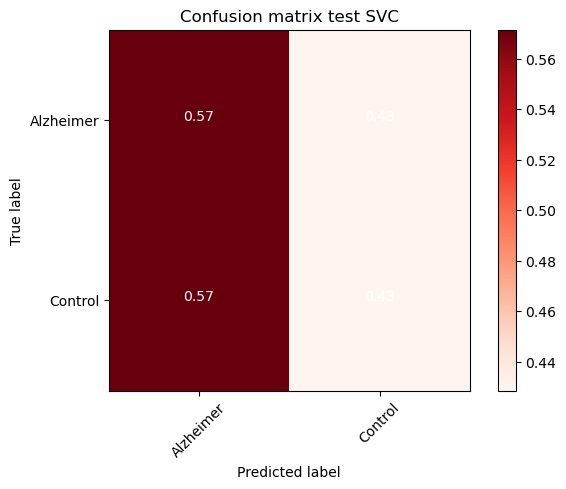

In [63]:
metrics2(best,"SVC",["Alzheimer","Control"])

#  Extreme Gradient boost

In [64]:
grad = GradientBoostingClassifier()
param_grid4 = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
grid_search = GridSearchCV(grad, 
                           param_grid4,
                           verbose=2,
                           scoring="f1_macro",
                           cv = ShuffleSplit(n_splits= 5, test_size=val_size),
                           n_jobs=-1)
grid_search.fit(Xtv, ytv)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best=GradientBoostingClassifier(n_estimators=best_params["n_estimators"],learning_rate=best_params["learning_rate"],max_depth=best_params["max_depth"])
best

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GradientBoostingClassifier(learning_rate=0.01, max_depth=4, n_estimators=50)

Train Gradient Boosting
------------


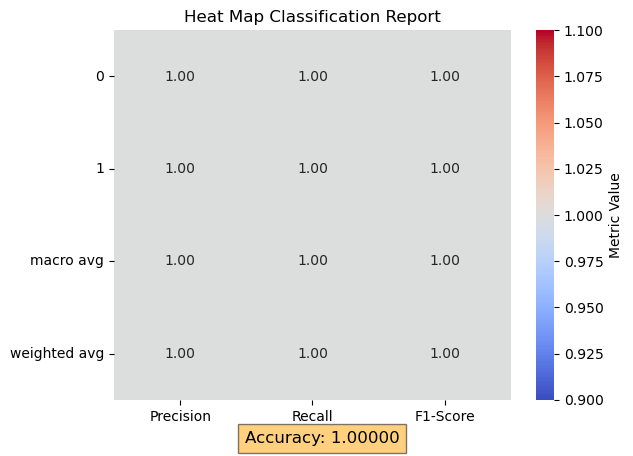

Normalized confusion matrix
------------
Test Gradient Boosting


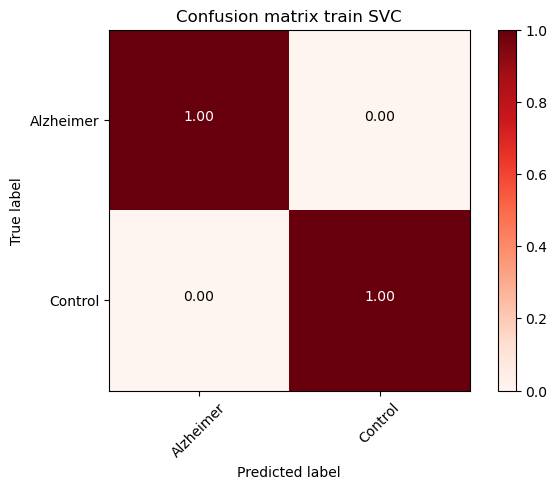

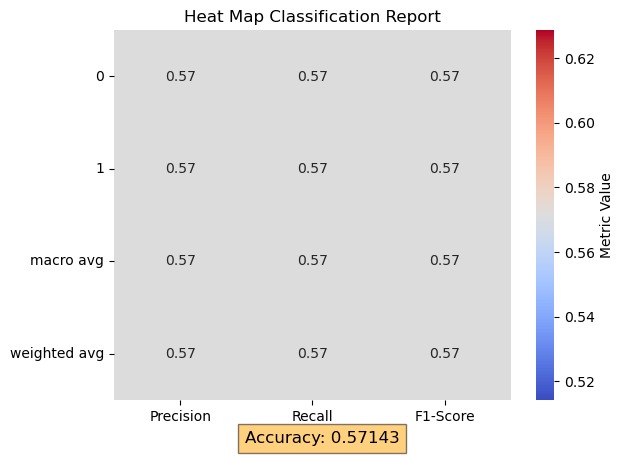

Normalized confusion matrix


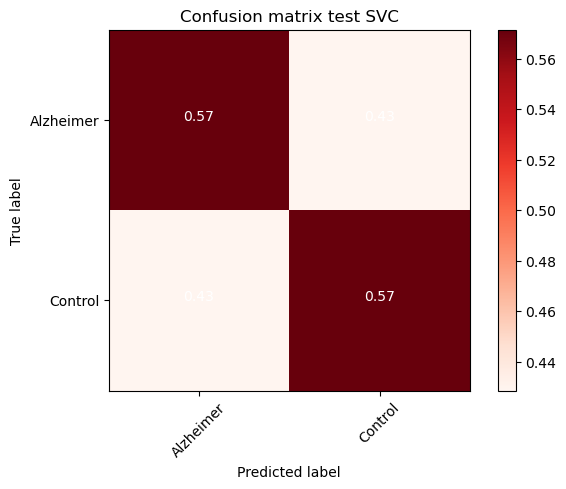

In [65]:
metrics2(best,"Gradient Boosting",["Alzheimer","Control"])